# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Load Dataset

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Customer_Churn_Prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# EDA (Exploratory Data Analysis)

In [3]:
# Total Number of Rows and Columns

df.shape

(7043, 21)

In [4]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# Statistical Summary

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
# Column Names

df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
# Missing values

df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
# Check Duplicate Values

df.duplicated().sum()

np.int64(0)

<Axes: >

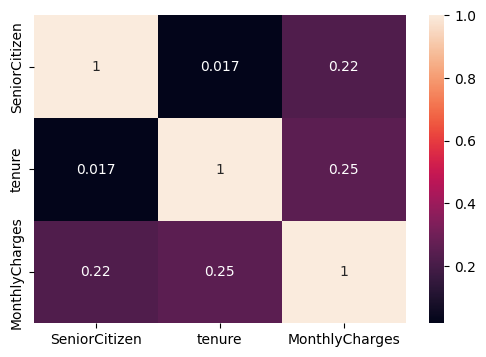

In [9]:
# Correlation Heatmap

plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [10]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


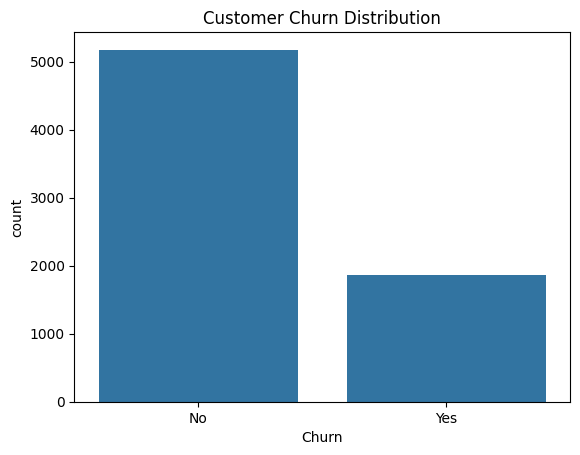

In [11]:
# Bar Chart

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")

plt.show()

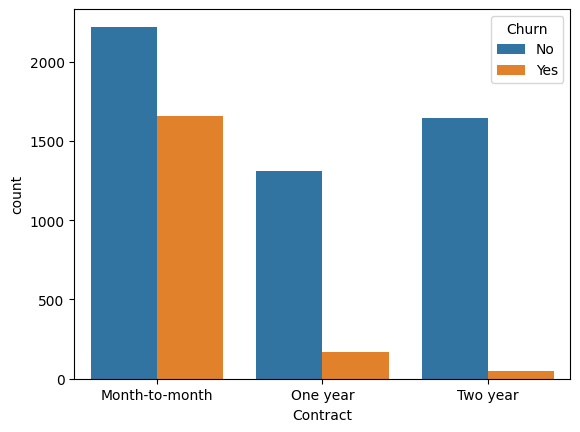

In [12]:
# Bar Chart

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)
plt.show()

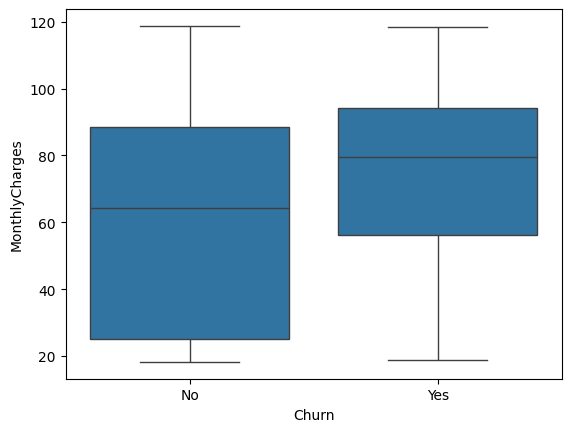

In [13]:
# Box Plot

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)
plt.show()

# Data Cleaning

In [14]:
# Convert TotalCharges Column into Numeric

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")

In [15]:
# Fill Missing Values

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [16]:
# Drop cutomerID Column

df.drop("customerID", axis=1, inplace=True)

In [17]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Encode Categorical Columns

In [18]:
df = pd.get_dummies(df,drop_first=True)

In [19]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


# Features & Target

In [20]:
X = df.drop("Churn_Yes", axis=1)
y = df["Churn_Yes"]

# Train Test Split

In [21]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Logistic Regression

In [32]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [33]:
# Accuracy Check

accuracy_score(y_test, lr_pred)

0.8211497515968772

In [24]:
# Confusion Matrix

confusion_matrix(y_test,lr_pred)

array([[933, 103],
       [149, 224]])

In [25]:
# Classification Report

print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

       False       0.86      0.90      0.88      1036
        True       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



# Decision Tree

In [26]:
tree = DecisionTreeClassifier(
    random_state=42
)

tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)

In [27]:
accuracy_score(y_test, tree_pred)

0.7097232079489

In [34]:
confusion_matrix(y_test,tree_pred)

array([[831, 205],
       [204, 169]])

In [35]:
print(classification_report(y_test,tree_pred))

              precision    recall  f1-score   support

       False       0.80      0.80      0.80      1036
        True       0.45      0.45      0.45       373

    accuracy                           0.71      1409
   macro avg       0.63      0.63      0.63      1409
weighted avg       0.71      0.71      0.71      1409



## Compare Models

| Model                        | Accuracy | Precision | Recall | F1 Score |
| ---------------------------- | -------- | --------- | ------ | -------- |
| Logistic Regression          | 82%      | 0.86      | 0.90   | 0.88     |
| Decision Tree                | 70%      | 0.80      | 0.80   | 0.80     |


# Feature Importance

In [36]:
importance = pd.Series(
    tree.feature_importances_,
    index=X.columns
)

importance.nlargest(3)

,0
tenure,0.204891
MonthlyCharges,0.202813
TotalCharges,0.196676


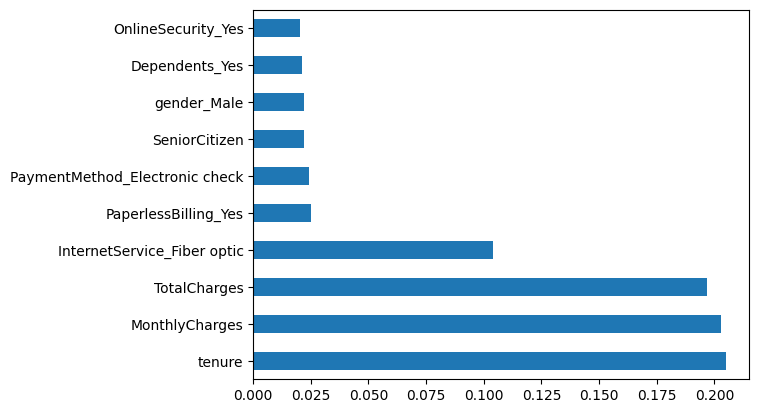

In [37]:
importance.nlargest(10).plot(
    kind="barh"
)

plt.show()

# Class Imbalance

The dataset is slightly imbalanced because there are more customers who stay than customers who leave.

This imbalance may affect the model by making it better at predicting the majority class.

In future work, techniques like SMOTE or class weighting can be used to improve performance.

# Business Summary

Customers with month-to-month contracts and higher monthly charges are more likely to leave.

Customers with longer tenure are less likely to churn.

The Decision Tree model helped identify the most important factors influencing customer churn.

These insights can help the company focus on retaining high-risk customers through better pricing, loyalty programs, or improved customer service.

# Save Model

In [38]:
import joblib

joblib.dump(lr,'/content/drive/MyDrive/Customer_Churn_Prediction/model.pkl')

['/content/drive/MyDrive/Customer_Churn_Prediction/model.pkl']

# Save training columns

In [41]:
joblib.dump(X.columns.tolist(), "/content/drive/MyDrive/Customer_Churn_Prediction/columns.pkl")

['/content/drive/MyDrive/Customer_Churn_Prediction/columns.pkl']

# Load Model

In [39]:
model = joblib.load('/content/drive/MyDrive/Customer_Churn_Prediction/model.pkl')